# Import libaraies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from google.colab import files

# Read Dataset

In [ ]:
files.upload()
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Features

## Who the customer is
- gender — the customer's gender
- SeniorCitizen — whether the customer is a senior citizen
- Partner — whether the customer has a spouse or partner living with them
- Dependents — whether the customer has dependents (kids, elderly parents, etc. relying on them)

## Their relationship with the company
- tenure — how many months they've been a customer so far
- Contract — what type of contract they're on: paying month-to-month with no commitment, or locked into a 1-year or 2-year agreement
- PaperlessBilling — whether they receive bills electronically instead of paper mail
- PaymentMethod — how they pay their bill (electronic check, mailed check, automatic bank transfer, or automatic credit card charge)
- MonthlyCharges — how much they're billed each month
- TotalCharges — the total amount they've paid the company across their entire time as a customer

## What services they've subscribed to

- PhoneService — whether they have a home phone line through this company
- MultipleLines — whether they have more than one phone line
- InternetService — what kind of internet they have (DSL, Fiber optic, or none)
- OnlineSecurity — whether they've added an online security add-on service
- OnlineBackup — whether they've added a cloud backup service
- DeviceProtection — whether they've added insurance/protection for their equipment (router, etc.)
- TechSupport — whether they've added a premium tech support service
- StreamingTV — whether they use the company's TV streaming service
- StreamingMovies — whether they use the company's movie streaming service

## The outcome you're predicting

- Churn — whether the customer ultimately left the company (cancelled service) or stayed

# EDA

In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
for feature in df.columns.drop('customerID'):
  print(feature, df[feature].unique())

gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges ['29.85' '1889

In [ ]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
binary_features =['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

In [ ]:
print(len(numerical_features + categorical_features + binary_features))
print(len(df.columns))

20
21


# Cleaning Data

In [ ]:
def encoding(df, feature):
    unique_vals = set(df[feature].dropna().unique())
    if unique_vals <= {'Yes', 'No'}:
        df[feature] = df[feature].map({'Yes': 1, 'No': 0})
    elif unique_vals <= {'Male', 'Female'}:
        df[feature] = df[feature].map({'Male': 1, 'Female': 0})
    else:
        print(f"Skipped '{feature}': unexpected values {unique_vals}")
    return df
for feature in binary_features:
  df = encoding(df, feature)

Skipped 'SeniorCitizen': unexpected values {np.int64(0), np.int64(1)}


In [ ]:
df[(df['TotalCharges'] == ' ') & (df['tenure']== 0)]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,0,1,1,0,0,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,1,Bank transfer (automatic),52.55,,0
753,3115-CZMZD,1,0,0,1,0,1,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.25,,0
936,5709-LVOEQ,0,0,1,1,0,1,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,0,Mailed check,80.85,,0
1082,4367-NUYAO,1,0,1,1,0,1,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.75,,0
1340,1371-DWPAZ,0,0,1,1,0,0,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,0,Credit card (automatic),56.05,,0
3331,7644-OMVMY,1,0,1,1,0,1,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,19.85,,0
3826,3213-VVOLG,1,0,1,1,0,1,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.35,,0
4380,2520-SGTTA,0,0,1,1,0,1,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.00,,0
5218,2923-ARZLG,1,0,1,1,0,1,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,1,Mailed check,19.70,,0
6670,4075-WKNIU,0,0,1,1,0,1,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,0,Mailed check,73.35,,0


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df['TotalCharges'].isna().sum()

np.int64(11)

In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [ ]:
(df['TotalCharges'] == 0.0).sum()

np.int64(11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  


In [ ]:
df[(df['TotalCharges'] != 0) & (df['tenure'] == 0)]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [ ]:
len(df[(df['tenure'] == 0) & (df['MonthlyCharges'] != 0)])

11

In [ ]:
df[df['tenure'] == 0]['MonthlyCharges']

,MonthlyCharges
488,52.55
753,20.25
936,80.85
1082,25.75
1340,56.05
3331,19.85
3826,25.35
4380,20.00
5218,19.70
6670,73.35


In [ ]:
len(df[(df['MonthlyCharges'] != 0) & (df['TotalCharges'] == 0)])

11

In [ ]:
df[df['TotalCharges'] == 0]['MonthlyCharges']

,MonthlyCharges
488,52.55
753,20.25
936,80.85
1082,25.75
1340,56.05
3331,19.85
3826,25.35
4380,20.00
5218,19.70
6670,73.35


# EDA Con.

In [ ]:
df[numerical_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


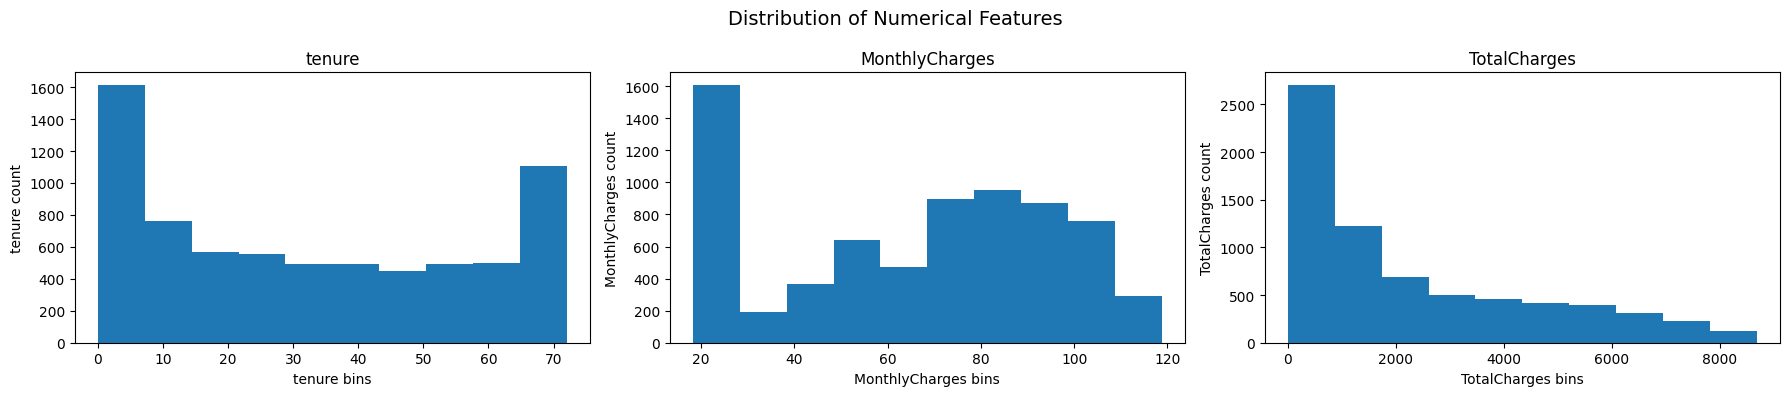

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, feature in enumerate(numerical_features):
  axes[i].set_title(feature)
  axes[i].hist(df[feature])
  axes[i].set_xlabel(f'{feature} bins')
  axes[i].set_ylabel(f'{feature} count')
fig.suptitle('Distribution of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print("""
We can conclude that
- tenure & MonthlyCharges are bimodal shapes
- TotalCharges is right-skew
""")


We can conclude that
- tenure & MonthlyCharges are bimodal shapes
- TotalCharges is right-skew



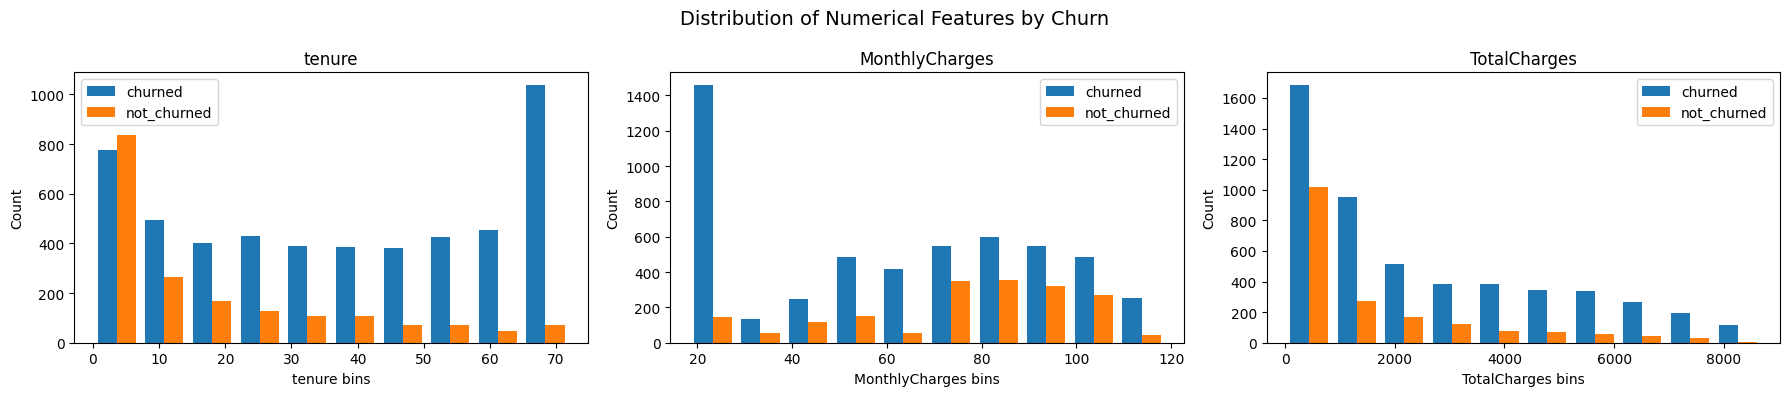

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, feature in enumerate(numerical_features):
    churned = df[df['Churn'] == 1][feature]
    not_churned = df[df['Churn'] == 0][feature]
    axes[i].hist([not_churned, churned])
    axes[i].set_title(feature)
    axes[i].set_xlabel(f'{feature} bins')
    axes[i].set_ylabel('Count')
    axes[i].legend(['churned', 'not_churned'])
fig.suptitle('Distribution of Numerical Features by Churn', fontsize=14)
plt.tight_layout()
plt.show()

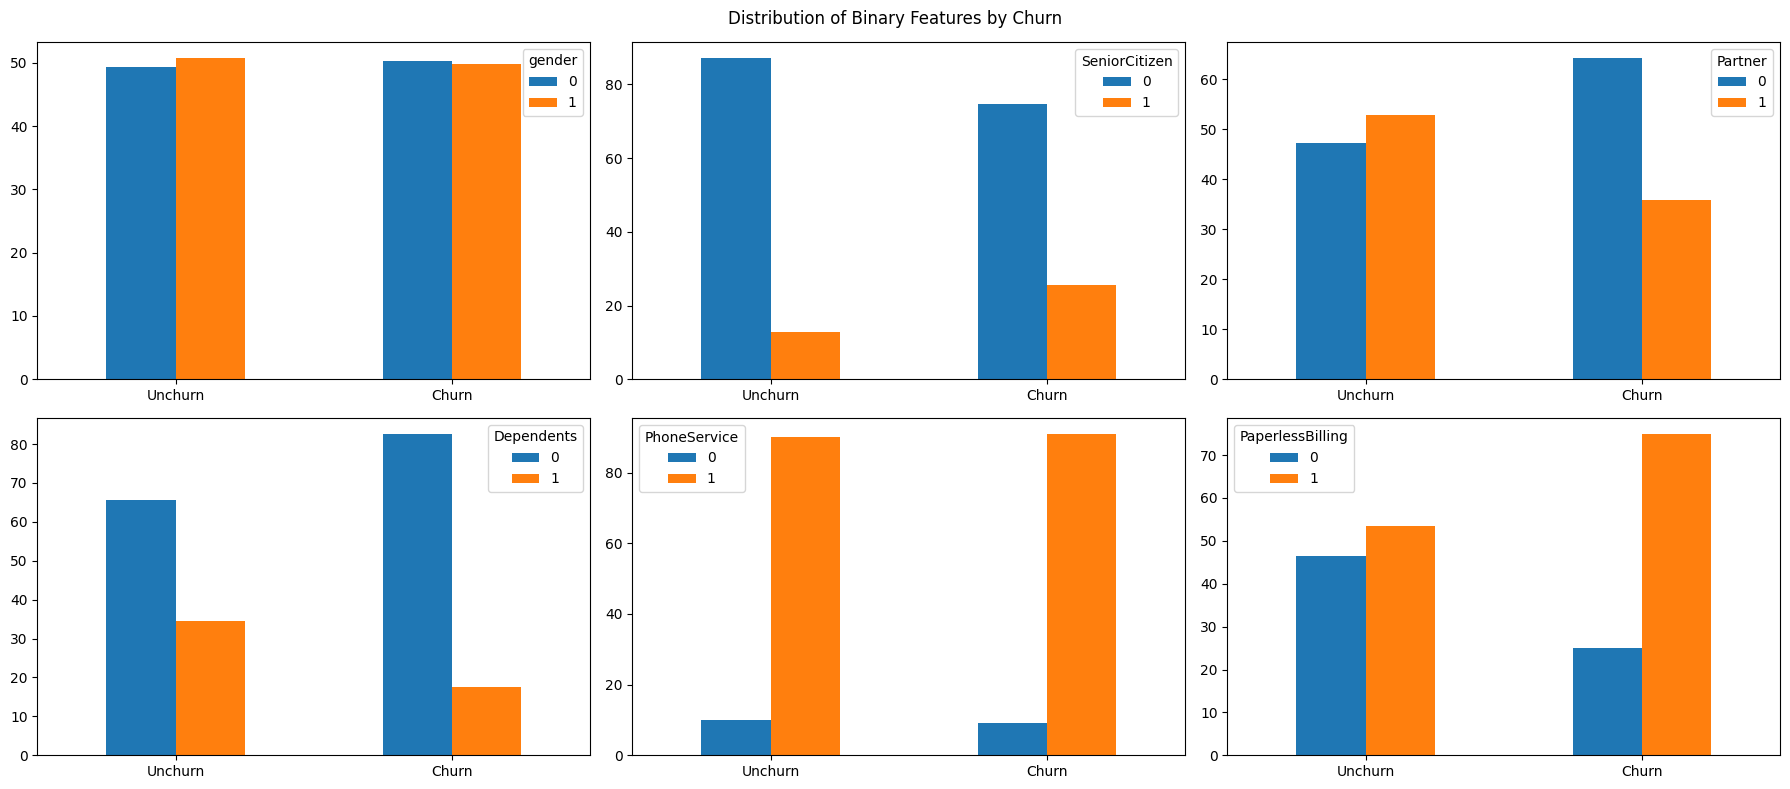

In [ ]:
binary_features_without_target = [f for f in binary_features if f != 'Churn']
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("Distribution of Binary Features by Churn")
for i, feature in enumerate(binary_features_without_target):
  ax = axes.flat[i]
  churn_cases = (df.groupby('Churn')[feature].value_counts(normalize=True) * 100).unstack(fill_value=0).sort_index()
  churn_cases.index=['Unchurn', 'Churn']
  churn_cases.plot(kind='bar', ax=ax)
  ax.tick_params(axis='x',rotation=0)
plt.tight_layout()
plt.show()

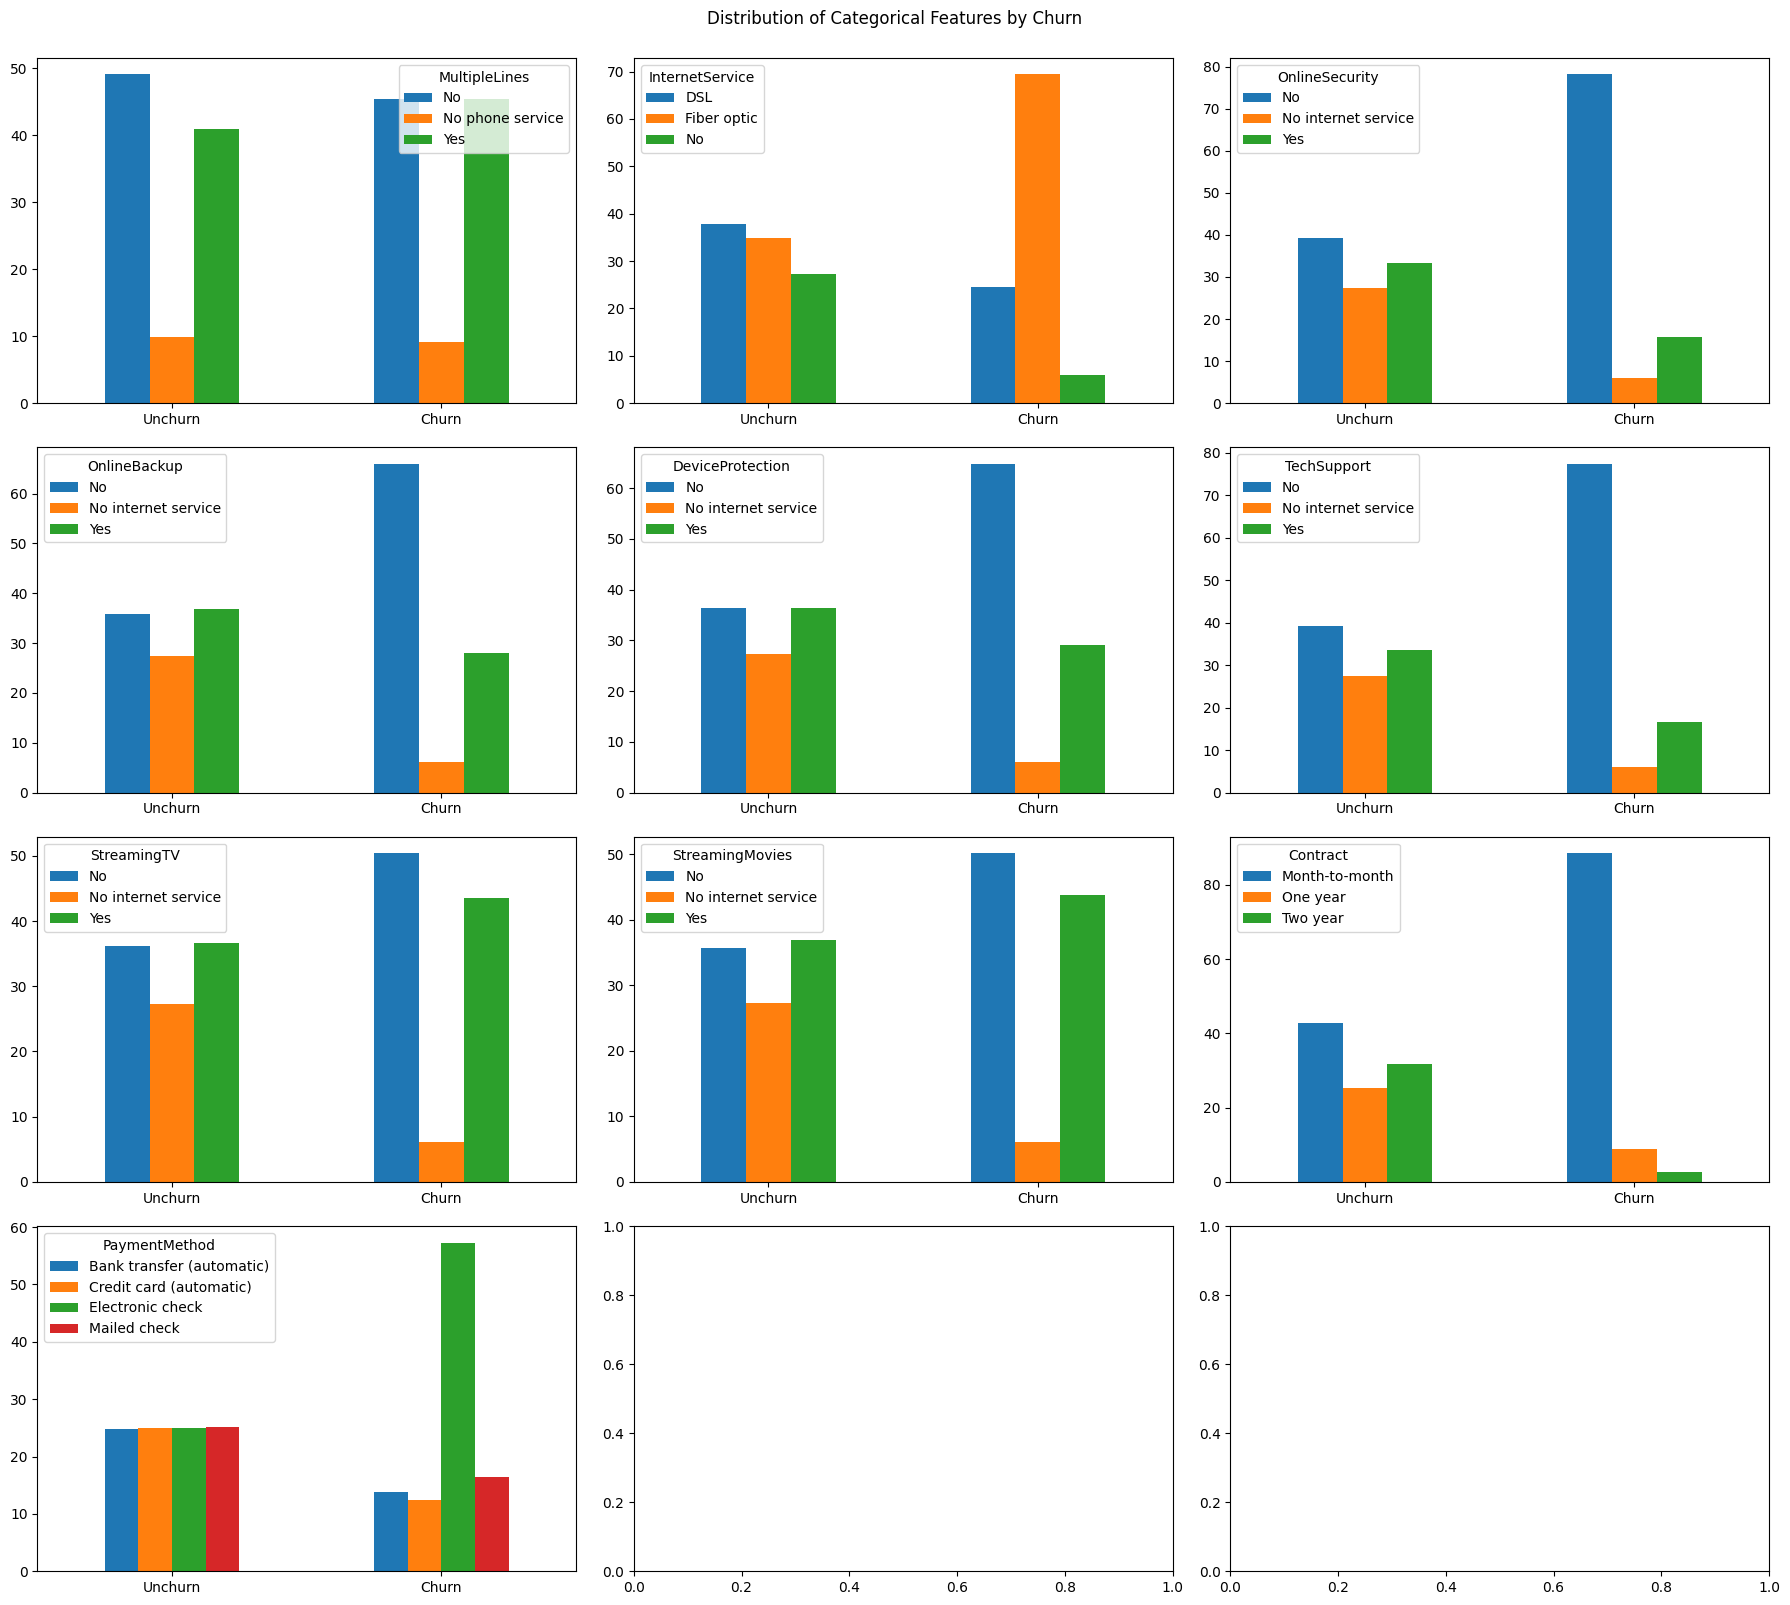

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.suptitle("Distribution of Categorical Features by Churn", y = 1)
for i, feature in enumerate(categorical_features):
  ax = axes.flat[i]
  churn_cases = (df.groupby('Churn')[feature].value_counts(normalize=True) * 100).unstack(fill_value=0).sort_index()
  churn_cases.index=['Unchurn', 'Churn']
  churn_cases.plot(kind='bar', ax=ax)
  ax.tick_params(axis='x',rotation=0)
plt.tight_layout()
plt.show()

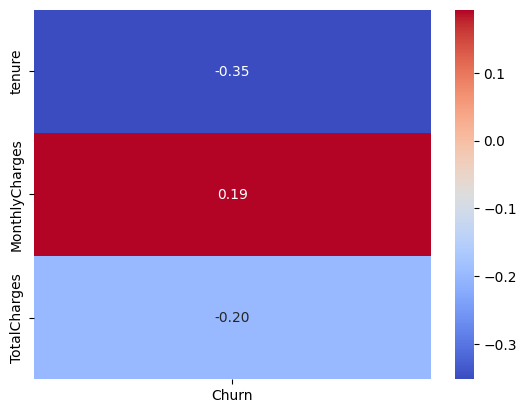

In [ ]:
numerical_features_corr = df[numerical_features + ['Churn']].corr()[['Churn']].drop(index='Churn')
sns.heatmap(numerical_features_corr, cmap='coolwarm', annot=True, fmt='0.2f')
plt.show()

# Model Pipeline

In [ ]:
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

full_pipline =  Pipeline([
    ('preprocessing', preprocessor),
    ('model', 'passthrough')
])

In [ ]:
param_grid = [{
        'model': [LogisticRegression()],
        'model__max_iter': [100, 250, 500, 1000],
        'model__class_weight': [None, 'balanced'],
        'model__C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'model': [DecisionTreeClassifier()],
        'model__class_weight': [None, 'balanced'],
        'model__max_depth': [50, 100, 200, 300, 500]
    },
    {
        'model':[MultinomialNB()],
        'model__alpha':[0.01, 0.1, 1, 10, 100],
        'model__force_alpha': [True, False]
    },
    {
        'model':[GaussianNB()],
        'model__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
    }]
grid = GridSearchCV(full_pipline, param_grid, cv=5, scoring='f1_macro')

In [ ]:
grid.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         MinMaxScaler(),
                                                                         ['tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'Stream...
                          'model__max_iter': [100, 250, 500, 1000]},
                         {'model': [DecisionTreeClassifier()],
                          'model__class_weight': [None, 'balanced'],
                          'model__max_depth': [50, 100, 200, 300, 500]},
                         {'model': [MultinomialNB()],
                          'model__alpha': [0.01, 0.1, 1, 10, 100],
                          'model__force_alpha': [True, False]},
                         {'model': [GaussianNB()],
                          'model__var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06,
                                                   1e-05, 0.0001, 0.001, 0.01,
                                                   0.1]}],
             scoring='f1_macro')

In [ ]:
"""
GridSearchCV does two things:
- It performs cross-validation for all the parameter combinations.
- After finding the best parameters, it automatically fits the best model on the entire X_train, y_train.
"""

'\nGridSearchCV does two things:\n- It performs cross-validation for all the parameter combinations.\n- After finding the best parameters, it automatically fits the best model on the entire X_train, y_train.\n'

In [ ]:
grid.best_params_

{'model': LogisticRegression(),
 'model__C': 100,
 'model__class_weight': None,
 'model__max_iter': 100}

In [ ]:
grid.best_score_

np.float64(0.7305273549923302)

In [ ]:
grid.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', MinMaxScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(C=100))])

In [ ]:
# scores = cross_validate(grid, X_train, y_train, cv=5, scoring=['f1', 'precision', 'recall'])

# print('f1', scores['test_f1'].mean())
# print('precision', scores['test_precision'].mean())
# print('recall', scores['test_recall'].mean())

In [ ]:
results = pd.DataFrame(grid.cv_results_)[['param_model', 'mean_test_score']]
results['param_model'] = results['param_model'].apply(lambda m: type(m).__name__)
results

,param_model,mean_test_score
0,LogisticRegression,0.705899
1,LogisticRegression,0.705899
2,LogisticRegression,0.705899
3,LogisticRegression,0.705899
4,LogisticRegression,0.706100
...,...,...
64,GaussianNB,0.667541
65,GaussianNB,0.667541
66,GaussianNB,0.667541
67,GaussianNB,0.667036


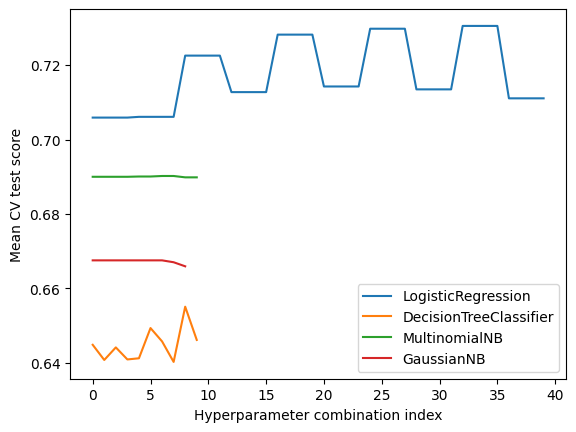

In [ ]:
for model in ['LogisticRegression', 'DecisionTreeClassifier', 'MultinomialNB', 'GaussianNB']:
  plt.plot(results[results['param_model'] == model]['mean_test_score'].reset_index(drop=True), label = model)
plt.legend()
plt.xlabel('Hyperparameter combination index')
plt.ylabel('Mean CV test score')
plt.show()

In [ ]:
grid.cv_results_

{'mean_fit_time': array([0.12143774, 0.13641572, 0.09539089, 0.05772252, 0.06301947,
        0.06095738, 0.06330857, 0.06599064, 0.06506715, 0.06782742,
        0.06544294, 0.07527518, 0.0618629 , 0.06037693, 0.06163116,
        0.0583992 , 0.06803913, 0.06140895, 0.05862846, 0.06582479,
        0.0642025 , 0.07258844, 0.06374168, 0.06599355, 0.06380978,
        0.06970677, 0.15417385, 0.17912941, 0.45233498, 0.13069777,
        0.08265018, 0.07865186, 0.07260857, 0.07074404, 0.07800422,
        0.07253065, 0.08685794, 0.07897725, 0.08571787, 0.08020444,
        0.06317506, 0.05994277, 0.05473285, 0.05473671, 0.05881896,
        0.05809031, 0.06100798, 0.05720911, 0.05663967, 0.06247411,
        0.0276947 , 0.04110875, 0.04725161, 0.04347906, 0.04278274,
        0.04196997, 0.04200969, 0.03996825, 0.04035606, 0.04053211,
        0.04793472, 0.03407965, 0.02671709, 0.02642379, 0.02753201,
        0.02617092, 0.02829394, 0.02809305, 0.02692089]),
 'std_fit_time': array([0.03460048, 0.023

In [ ]:
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1294
           1       0.66      0.55      0.60       467

    accuracy                           0.80      1761
   macro avg       0.75      0.72      0.74      1761
weighted avg       0.80      0.80      0.80      1761



0.848711231875664


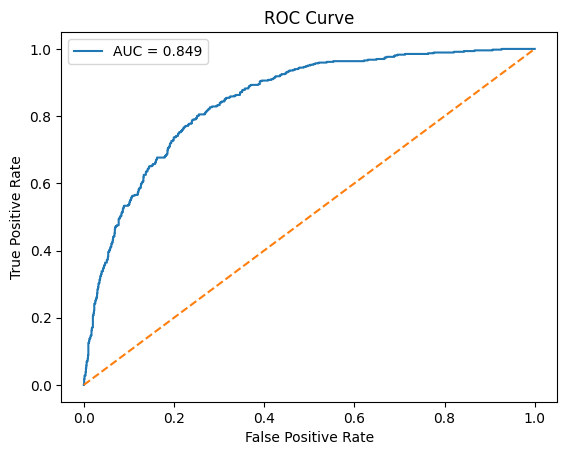

In [ ]:
y_proba = grid.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print(roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()